In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
metrics_json_paths = glob('./logs/finetune_20250703/*/*/*/*/*/*/*/assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 31 metrics JSON files.


In [3]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    for i, part in enumerate(split_path_parts):
        print(f'Part {i}: {part}')
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[6] == 'frozenencoder_true'
    n_train = split_path_parts[7]
    fold = split_path_parts[8].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

Part 0: .
Part 1: logs
Part 2: finetune_20250703
Part 3: unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_true
Part 7: 250
Part 8: fold_4
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250703
Part 3: unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_true
Part 7: 250
Part 8: fold_3
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250703
Part 3: unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_true
Part 7: 250
Part 8: fold_2
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250703
Part 3: unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_true
Part 7: 250
Part 8: fold_1
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250703
Part 3: unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_true
Part 7: 500
Part 8: fold_4
Part 9: test
Part 10: assessment_metrics.json
Part 0: .


,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
12,0.853246,0.853246,0.853246,0.853246,0.744053,0.744019,1.667577,0.038129,0.698301,0.734955,...,0.852429,0.853246,0.757470,1.667577,0.038129,unet,byol,False,250,1
14,0.854526,0.854526,0.854526,0.854526,0.746002,0.746159,1.608784,0.032664,0.685439,0.731478,...,0.858049,0.854526,0.759133,1.608784,0.032664,unet,byol,False,500,2
15,0.848726,0.848726,0.848726,0.848726,0.737206,0.736890,1.628169,0.034500,0.680765,0.716520,...,0.852629,0.848726,0.753657,1.628169,0.034500,unet,byol,False,500,1
10,0.841406,0.841406,0.841406,0.841406,0.726231,0.724859,1.719314,0.044151,0.670786,0.712402,...,0.843102,0.841406,0.742820,1.719314,0.044151,unet,byol,False,250,3
28,0.836927,0.836927,0.836927,0.836927,0.719582,0.715379,1.679550,0.039924,0.642105,0.711515,...,0.834714,0.836927,0.736358,1.679550,0.039924,unet,imagenet,False,500,3
13,0.842726,0.842726,0.842726,0.842726,0.728200,0.726931,1.646355,0.036480,0.636133,0.702733,...,0.851585,0.842726,0.746303,1.646355,0.036480,unet,byol,False,500,3
20,0.813887,0.813887,0.813887,0.813887,0.686181,0.680903,1.617286,0.035851,0.628997,0.682059,...,0.826549,0.813887,0.710081,1.617286,0.035851,unet,imagenet,True,500,3
8,0.811008,0.811008,0.811008,0.811008,0.682096,0.680202,1.649552,0.040710,0.627677,0.667937,...,0.822929,0.811008,0.705755,1.649552,0.040710,unet,byol,True,500,1
3,0.816487,0.816487,0.816487,0.816487,0.689885,0.686575,1.782651,0.053567,0.613467,0.638276,...,0.820748,0.816487,0.712136,1.782651,0.053567,unet,byol,True,250,1
21,0.837207,0.837207,0.837207,0.837207,0.719996,0.711899,1.660630,0.037838,0.612317,0.686988,...,0.837980,0.837207,0.731492,1.660630,0.037838,unet,imagenet,True,500,2


In [4]:
metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).count()

accuracy  f1_score  precision  \
model pretrain_method frozen_encoder n_train                                  
unet  byol            False          250             4         4          4   
                                     500             3         3          3   
                      True           250             4         4          4   
                                     500             5         5          5   
      imagenet        False          250             4         4          4   
                                     500             4         4          4   
                      True           250             4         4          4   
                                     500             3         3          3   

                                              recall  jaccard  kappa  \
model pretrain_method frozen_encoder n_train                           
unet  byol            False          250           4        4      4   
                                     500           3        3      3   
                      True           250           4        4      4   
                                     500           5        5      5   
      imagenet        False          250           4        4      4   
                                     500           4        4      4   
                      True           250           4        4      4   
                                     500           3        3      3   

                                              cross_entropy  brier_score  \
model pretrain_method frozen_encoder n_train                               
unet  byol            False          250                  4            4   
                                     500                  3            3   
                      True           250                  4            4   
                                     500                  5            5   
      imagenet        False          250                  4            4   
                                     500                  4            4   
                      True           250                  4            4   
                                     500                  3            3   

                                              macro_f1_score  macro_precision  \
model pretrain_method frozen_encoder n_train                                    
unet  byol            False          250                   4                4   
                                     500                   3                3   
                      True           250                   4                4   
                                     500                   5                5   
      imagenet        False          250                   4                4   
                                     500                   4                4   
                      True           250                   4                4   
                                     500                   3                3   

                                              ...  macro_jaccard  \
model pretrain_method frozen_encoder n_train  ...                  
unet  byol            False          250      ...              4   
                                     500      ...              3   
                      True           250      ...              4   
                                     500      ...              5   
      imagenet        False          250      ...              4   
                                     500      ...              4   
                      True           250      ...              4   
                                     500      ...              3   

                                              macro_cross_entropy  \
model pretrain_method frozen_encoder n_train                        
unet  byol            False          250                        4   
                                     500                        3   
     

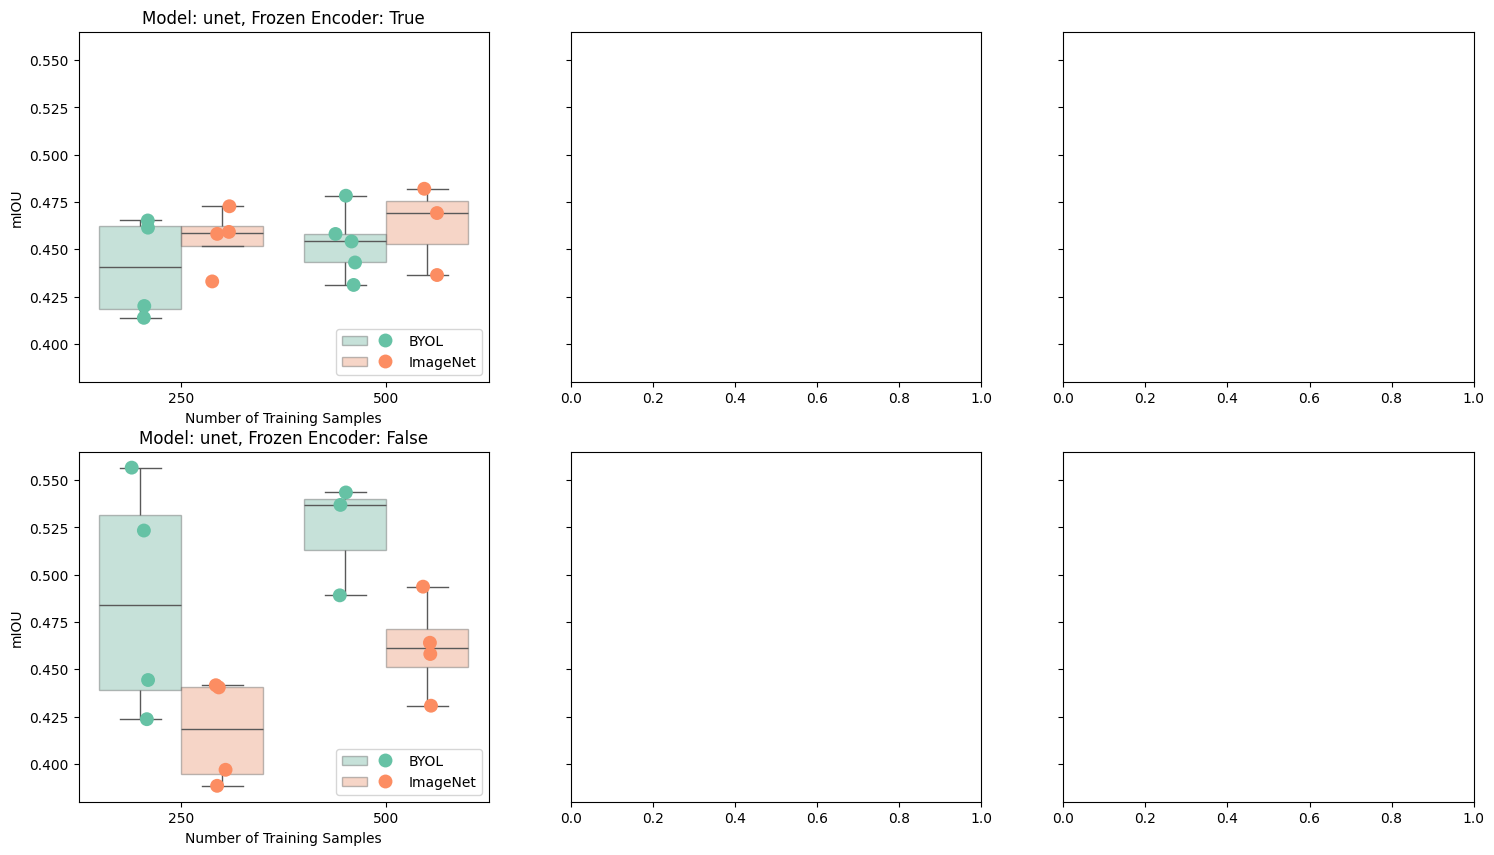

In [5]:
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
    # print(i, model)
    for j, model in enumerate(metrics_df['model'].unique()):
        # metrics_df['model']
        # print(j, frozen_encoder)
        subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
        # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
        # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
        # sns.pointplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j], dodge=True, errorbar='iqr')
        sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
        sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], jitter=True, dodge=True, palette='Set2', size=10)
        handles, labels = ax[i, j].get_legend_handles_labels()
        ax[i, j].legend(handles=[(handles[0], handles[2]), (handles[1], handles[3])],
                labels=['BYOL', 'ImageNet'],
                loc='lower right', handlelength=4,
                handler_map={tuple: HandlerTuple(ndivide=None)})
        ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
        ax[i, j].set_xlabel('Number of Training Samples')
        ax[i, j].set_ylabel('mIOU')

In [6]:
metrics_reduced_df = metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).agg({
    'macro_f1_score': ['mean', 'std'],
    'macro_jaccard': ['mean', 'std'],
    'f1_score': ['mean', 'std'],
    # 'precision': ['mean', 'std'],
    # 'recall': ['mean', 'std']
}).reset_index()
# Optionally, flatten the MultiIndex columns
metrics_reduced_df.columns = ['_'.join(col).strip('_') for col in metrics_reduced_df.columns.values]
metrics_reduced_df.sort_values(by='macro_jaccard_mean', ascending=False)

,model,pretrain_method,frozen_encoder,n_train,macro_f1_score_mean,macro_f1_score_std,macro_jaccard_mean,macro_jaccard_std,f1_score_mean,f1_score_std
1,unet,byol,False,500,0.667446,0.027218,0.523192,0.029682,0.848659,0.005900
0,unet,byol,False,250,0.630741,0.063780,0.487019,0.063252,0.827587,0.023428
7,unet,imagenet,True,500,0.606223,0.026355,0.462558,0.023516,0.823420,0.012228
5,unet,imagenet,False,500,0.604672,0.028124,0.461676,0.025811,0.825087,0.008046
6,unet,imagenet,True,250,0.601007,0.014939,0.455811,0.016568,0.819527,0.010392
3,unet,byol,True,500,0.596921,0.021103,0.452986,0.017644,0.812967,0.003717
2,unet,byol,True,250,0.585269,0.027967,0.440158,0.026973,0.810958,0.016685
4,unet,imagenet,False,250,0.554218,0.035152,0.416859,0.028135,0.806408,0.013971


In [ ]:
# group 
import scipy.stats as stats

# Choose the metric to compare
metric = 'macro_'

# Store results
test_results = []

# Loop over groups
for (model, frozen_encoder, n_train), group in metrics_df.groupby(['model', 'frozen_encoder', 'n_train']):
    # Pivot so each method's results are columns, indexed by fold
    pivot = group.pivot(index='fold', columns='pretrain_method', values=metric)
    # Only test if both methods are present and have at least 2 folds
    if {'byol', 'imagenet'}.issubset(pivot.columns) and len(pivot) > 1:
        # Drop NaNs (in case some folds are missing)
        byol = pivot['byol'].dropna()
        imagenet = pivot['imagenet'].dropna()
        # Align folds
        common_folds = byol.index.intersection(imagenet.index)
        if len(common_folds) > 1:
            stat, p = stats.ttest_rel(byol.loc[common_folds], imagenet.loc[common_folds])
            test_results.append({
                'model': model,
                'frozen_encoder': frozen_encoder,
                'n_train': n_train,
                'statistic': stat,
                'p_value': p,
                'byol_mean': byol.loc[common_folds].mean(),
                'imagenet_mean': imagenet.loc[common_folds].mean(),
                'n_folds': len(common_folds)
            })

# Show results as DataFrame
test_results_df = pd.DataFrame(test_results)
display(test_results_df.sort_values('p_value'))

,model,frozen_encoder,n_train,statistic,p_value,byol_mean,imagenet_mean,n_folds
0,unet,False,250,2.071519,0.130053,0.487019,0.416859,4
1,unet,False,500,1.808477,0.212259,0.523192,0.462858,3
2,unet,True,250,-1.553487,0.218130,0.440158,0.455811,4
3,unet,True,500,-0.113956,0.919681,0.459855,0.462558,3
